#Data Cleaning


In [1]:
from google.colab import files

uploaded = files.upload()

Saving bank-full.csv to bank-full.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("bank-full.csv", sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop_duplicates()

In [8]:
df['converted'] = df['y'].map({
    'yes':1,
    'no':0
})

df[['y','converted']].head()

,y,converted
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


In [9]:
df['converted'].value_counts()

,count
converted,
0,39922
1,5289


In [10]:
df['converted'].value_counts(normalize=True)*100

,proportion
converted,
0,88.30152
1,11.69848


In [11]:
#create funnel stages
contacts = len(df)

engaged = len(df[df['duration'] > 0])

qualified = len(df[df['campaign'] > 1])

customers = len(df[df['converted'] == 1])

funnel = pd.DataFrame({
    'Stage': ['Contacts',
              'Engaged Leads',
              'Qualified Leads',
              'Customers'],
    'Count': [contacts,
              engaged,
              qualified,
              customers]
})

funnel

,Stage,Count
0,Contacts,45211
1,Engaged Leads,45208
2,Qualified Leads,27667
3,Customers,5289


In [12]:
#Calculate Conversion Rates
funnel['Conversion Rate (%)'] = (
    funnel['Count']
    /
    funnel['Count'].shift(1)
)*100

funnel.loc[0,'Conversion Rate (%)'] = 100

funnel

,Stage,Count,Conversion Rate (%)
0,Contacts,45211,100.000000
1,Engaged Leads,45208,99.993364
2,Qualified Leads,27667,61.199345
3,Customers,5289,19.116637


In [13]:
#Calculate Drop-Offs
funnel['Drop-Off (%)'] = (
    100 -
    funnel['Conversion Rate (%)']
)

funnel

,Stage,Count,Conversion Rate (%),Drop-Off (%)
0,Contacts,45211,100.000000,0.000000
1,Engaged Leads,45208,99.993364,0.006636
2,Qualified Leads,27667,61.199345,38.800655
3,Customers,5289,19.116637,80.883363


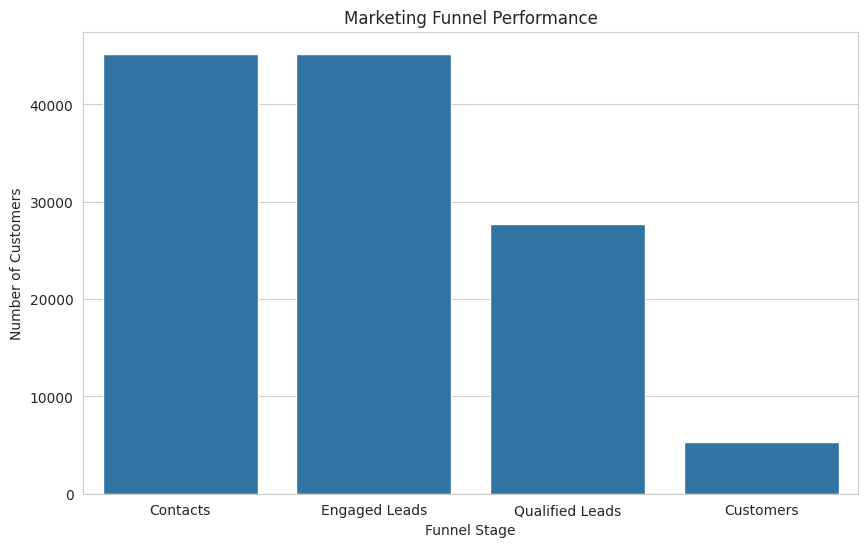

In [14]:
#Funnel Chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=funnel,
    x='Stage',
    y='Count'
)

plt.title("Marketing Funnel Performance")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Customers")

plt.show()

In [15]:
plt.savefig(
    "funnel_chart.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [17]:
#Channel Performance Analysis

df['contact'].value_counts()

,count
contact,
cellular,29285
unknown,13020
telephone,2906


In [18]:
channel_perf = (
    df.groupby('contact')['converted']
      .mean()
      .sort_values(ascending=False)
      *100
)

channel_perf

,converted
contact,
cellular,14.918900
telephone,13.420509
unknown,4.070661


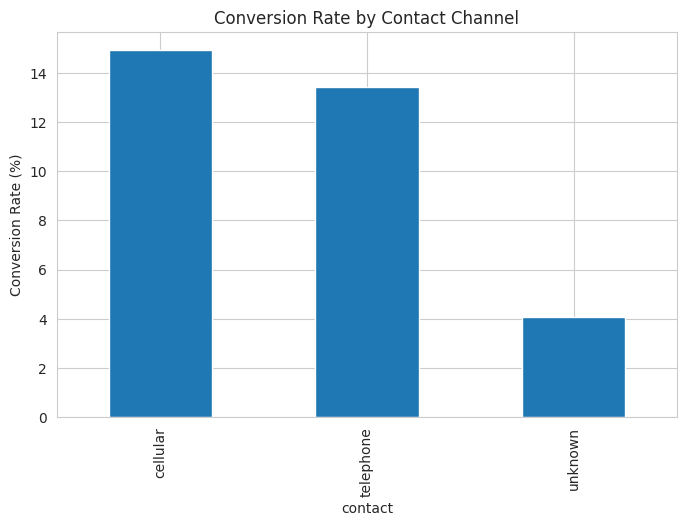

In [19]:
plt.figure(figsize=(8,5))

channel_perf.plot(
    kind='bar'
)

plt.title("Conversion Rate by Contact Channel")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [20]:
plt.savefig(
    "channel_conversion.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [21]:
#Monthly Conversion Analysis
monthly_conversion = (
    df.groupby('month')['converted']
      .mean()
      *100
)

monthly_conversion

,converted
month,
apr,19.679400
aug,11.013286
dec,46.728972
feb,16.647792
jan,10.121169
jul,9.093546
jun,10.222805
mar,51.991614
may,6.719454


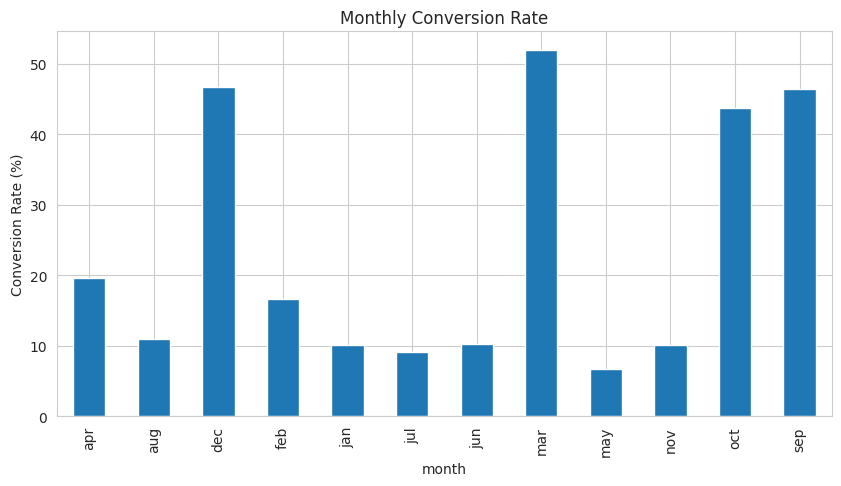

In [22]:
plt.figure(figsize=(10,5))

monthly_conversion.plot(
    kind='bar'
)

plt.title("Monthly Conversion Rate")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [23]:
plt.savefig(
    "monthly_conversion.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [24]:
#Campaign Effectiveness
campaign_perf = (
    df.groupby('campaign')['converted']
      .mean()
      *100
)

campaign_perf.head(20)

,converted
campaign,
1,14.597583
2,11.203519
3,11.193624
4,9.000568
5,7.879819
6,7.126259
7,6.394558
8,5.925926
9,6.422018


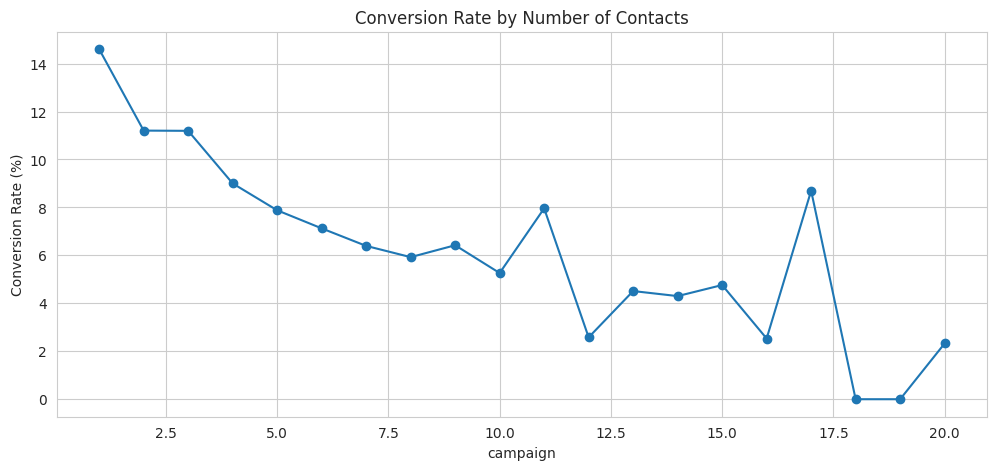

In [25]:
plt.figure(figsize=(12,5))

campaign_perf.head(20).plot(
    marker='o'
)

plt.title("Conversion Rate by Number of Contacts")
plt.ylabel("Conversion Rate (%)")

plt.show()

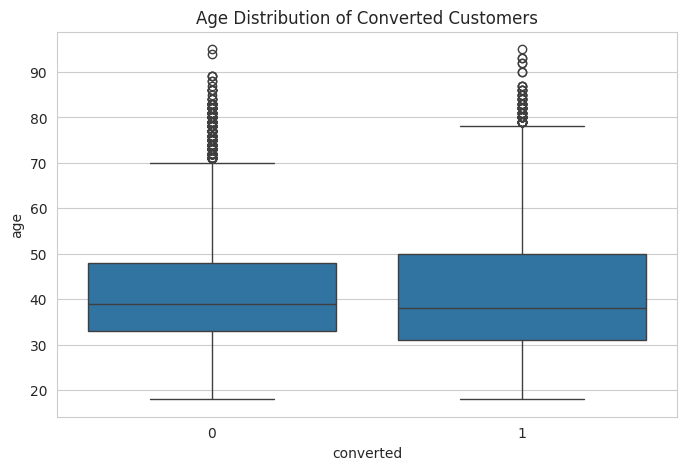

In [26]:
#Age analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='converted',
    y='age'
)

plt.title("Age Distribution of Converted Customers")

plt.show()

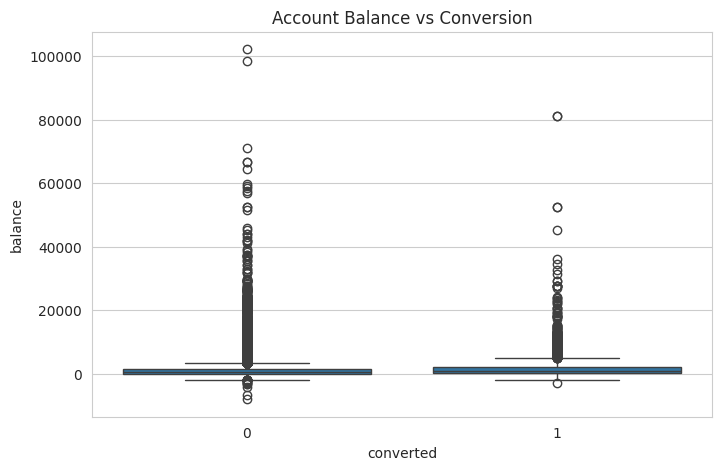

In [27]:
#Balance analysis
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='converted',
    y='balance'
)

plt.title("Account Balance vs Conversion")

plt.show()

In [28]:
#KPI Summary
total_contacts = len(df)

total_customers = df['converted'].sum()

overall_conversion = (
    total_customers /
    total_contacts
)*100

print("Total Contacts:", total_contacts)

print("Converted Customers:", total_customers)

print("Overall Conversion Rate:",
      round(overall_conversion,2),
      "%")

Total Contacts: 45211
Converted Customers: 5289
Overall Conversion Rate: 11.7 %


In [29]:
#create final dashboard table
summary = pd.DataFrame({

    'Metric':[
        'Total Contacts',
        'Converted Customers',
        'Overall Conversion Rate (%)'
    ],

    'Value':[
        total_contacts,
        total_customers,
        round(overall_conversion,2)
    ]
})

summary

,Metric,Value
0,Total Contacts,45211.0
1,Converted Customers,5289.0
2,Overall Conversion Rate (%),11.7


In [30]:
contacts = len(df)

reached = len(df[df['contact'] != 'unknown'])

engaged = len(df[df['duration'] > 120])

customers = len(df[df['converted'] == 1])

funnel = pd.DataFrame({
    'Stage':[
        'Contacts',
        'Reached',
        'Engaged',
        'Customers'
    ],
    'Count':[
        contacts,
        reached,
        engaged,
        customers
    ]
})

funnel

,Stage,Count
0,Contacts,45211
1,Reached,32191
2,Engaged,31167
3,Customers,5289


#Dashboard code

In [33]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px


# Page Configuration

st.set_page_config(
    page_title="Marketing Funnel Analysis Dashboard",
    layout="wide"
)


# Load Data

@st.cache_data
def load_data():
    import os

    file_path = os.path.join(os.path.dirname(__file__), "bank-full.csv")

    df = pd.read_csv(file_path, sep=";")
    df["converted"] = df["y"].map({"yes": 1, "no": 0})

    return df

df = load_data()


# Sidebar

st.sidebar.title("Filters")

contact_filter = st.sidebar.multiselect(
    "Contact Type",
    options=df["contact"].unique(),
    default=df["contact"].unique()
)

month_filter = st.sidebar.multiselect(
    "Month",
    options=df["month"].unique(),
    default=df["month"].unique()
)

filtered_df = df[
    (df["contact"].isin(contact_filter))
    &
    (df["month"].isin(month_filter))
]


# Title


st.title(" Marketing Funnel & Conversion Analysis Dashboard")

st.markdown("""
Analyze conversion performance, funnel drop-offs,
marketing channels, and customer behavior.
""")


# KPI SECTION


total_contacts = len(filtered_df)

customers = filtered_df["converted"].sum()

conversion_rate = (
    customers / total_contacts * 100
)

avg_duration = filtered_df["duration"].mean()

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Total Contacts",
    f"{total_contacts:,}"
)

col2.metric(
    "Customers",
    f"{customers:,}"
)

col3.metric(
    "Conversion Rate",
    f"{conversion_rate:.2f}%"
)

col4.metric(
    "Avg Call Duration",
    f"{avg_duration:.0f} sec"
)


# FUNNEL


st.subheader("Marketing Funnel")

contacts = len(filtered_df)

reached = len(
    filtered_df[
        filtered_df["contact"] != "unknown"
    ]
)

engaged = len(
    filtered_df[
        filtered_df["duration"] > 120
    ]
)

converted = len(
    filtered_df[
        filtered_df["converted"] == 1
    ]
)

funnel_df = pd.DataFrame({
    "Stage": [
        "Contacts",
        "Reached",
        "Engaged",
        "Customers"
    ],
    "Count": [
        contacts,
        reached,
        engaged,
        converted
    ]
})

fig_funnel = px.funnel(
    funnel_df,
    x="Count",
    y="Stage",
    title="Marketing Funnel"
)

st.plotly_chart(
    fig_funnel,
    use_container_width=True
)


# CHANNEL PERFORMANCE


st.subheader("Conversion by Contact Channel")

channel_perf = (
    filtered_df
    .groupby("contact")["converted"]
    .mean()
    .reset_index()
)

channel_perf["converted"] *= 100

fig_channel = px.bar(
    channel_perf,
    x="contact",
    y="converted",
    color="contact",
    title="Channel Conversion Rate (%)"
)

st.plotly_chart(
    fig_channel,
    use_container_width=True
)


# MONTHLY PERFORMANCE


st.subheader("Monthly Conversion Performance")

monthly_perf = (
    filtered_df
    .groupby("month")["converted"]
    .mean()
    .reset_index()
)

monthly_perf["converted"] *= 100

month_order = [
    "jan","feb","mar","apr","may","jun",
    "jul","aug","sep","oct","nov","dec"
]

monthly_perf["month"] = pd.Categorical(
    monthly_perf["month"],
    categories=month_order,
    ordered=True
)

monthly_perf = monthly_perf.sort_values("month")

fig_month = px.line(
    monthly_perf,
    x="month",
    y="converted",
    markers=True,
    title="Monthly Conversion Rate (%)"
)

st.plotly_chart(
    fig_month,
    use_container_width=True
)


# CAMPAIGN EFFECTIVENESS


st.subheader("Campaign Effectiveness")

campaign_perf = (
    filtered_df
    .groupby("campaign")["converted"]
    .mean()
    .reset_index()
)

campaign_perf["converted"] *= 100

fig_campaign = px.line(
    campaign_perf.head(20),
    x="campaign",
    y="converted",
    markers=True,
    title="Conversion Rate by Number of Contacts"
)

st.plotly_chart(
    fig_campaign,
    use_container_width=True
)


# AGE ANALYSIS

st.subheader("Age Distribution")

fig_age = px.box(
    filtered_df,
    x="converted",
    y="age",
    title="Age vs Conversion"
)

st.plotly_chart(
    fig_age,
    use_container_width=True
)


# BALANCE ANALYSIS

st.subheader("Balance Distribution")

fig_balance = px.box(
    filtered_df,
    x="converted",
    y="balance",
    title="Balance vs Conversion"
)

st.plotly_chart(
    fig_balance,
    use_container_width=True
)

# INSIGHTS


st.subheader("Key Business Insights")

st.markdown("""
### Key Findings

- Funnel visualization identifies major drop-off stages.
- Channel performance reveals which contact method drives the highest conversions.
- Monthly analysis highlights seasonal conversion trends.
- Campaign analysis shows whether repeated contact improves conversion.
- Customer demographics help identify high-value customer segments.

### Recommendations

- Invest more in top-performing channels.
- Improve engagement at the largest drop-off stage.
- Increase marketing efforts during high-converting months.
- Optimize campaign contact frequency.
- Target customer profiles with higher conversion likelihood.
""")

Overwriting app.py


In [31]:
%%writefile requirements.txt
streamlit
pandas
numpy
matplotlib
seaborn
plotly

Writing requirements.txt
